In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("./wine_data.csv", header=None, usecols=[0,1,2])
df.columns = ["Class Label", "Alcohol", "Malic Acid"]

In [23]:
df.sample(5)

,Class Label,Alcohol,Malic Acid
42,1,13.88,1.89
54,1,13.74,1.67
163,3,12.96,3.45
128,2,12.37,1.63
89,2,12.08,1.33


<Axes: xlabel='Alcohol', ylabel='Density'>

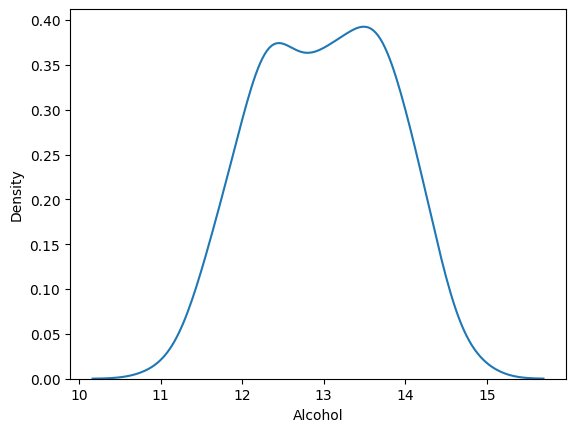

In [24]:
sns.kdeplot(df, x="Alcohol")

<Axes: xlabel='Malic Acid', ylabel='Density'>

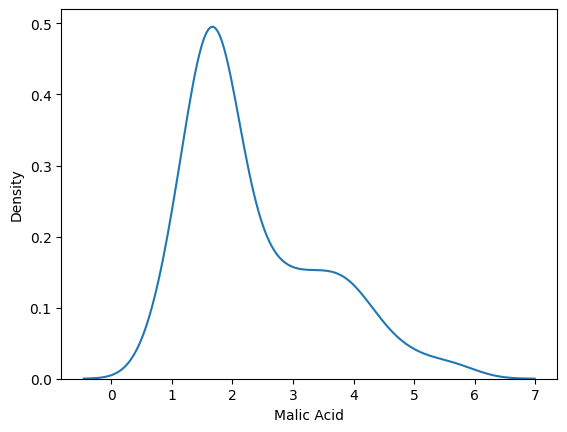

In [25]:
sns.kdeplot(df, x="Malic Acid")

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

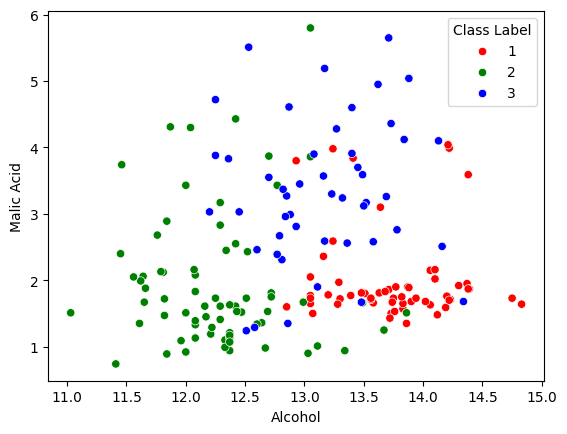

In [36]:
class_color_palette = {1: "red", 2:"green", 3: "blue"}
sns.scatterplot(df, x="Alcohol", y="Malic Acid", hue="Class Label", palette=class_color_palette)

In [27]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop("Class Label", axis=1),
    df["Class Label"],
    test_size=0.3,
    random_state=0
)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [32]:
np.round(X_train.describe(), 1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [33]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


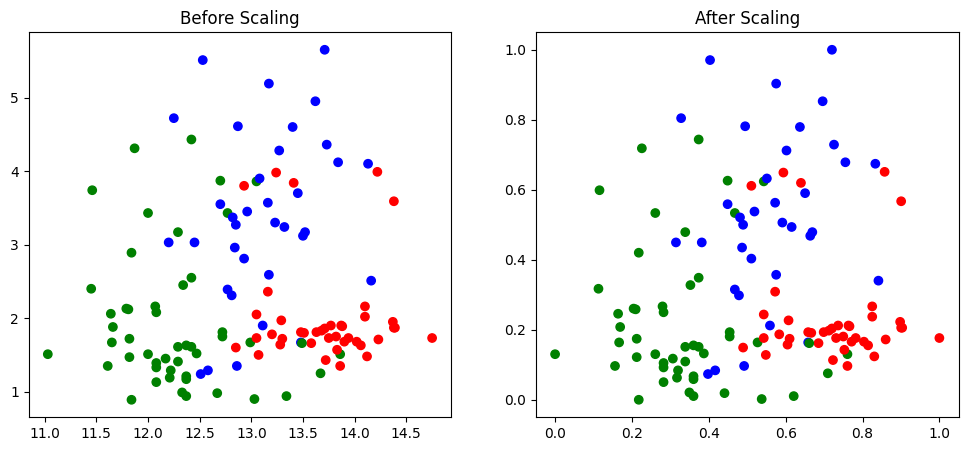

In [58]:
import matplotlib
import matplotlib.colors

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

cmap=matplotlib.colors.ListedColormap(class_color_palette.values())
ax1.scatter(X_train['Alcohol'], X_train['Malic Acid'],c=y_train,cmap=cmap)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic Acid'],c=y_train,cmap=cmap)
ax2.set_title("After Scaling")
plt.show()

Distribution is not different, but the scale is changed

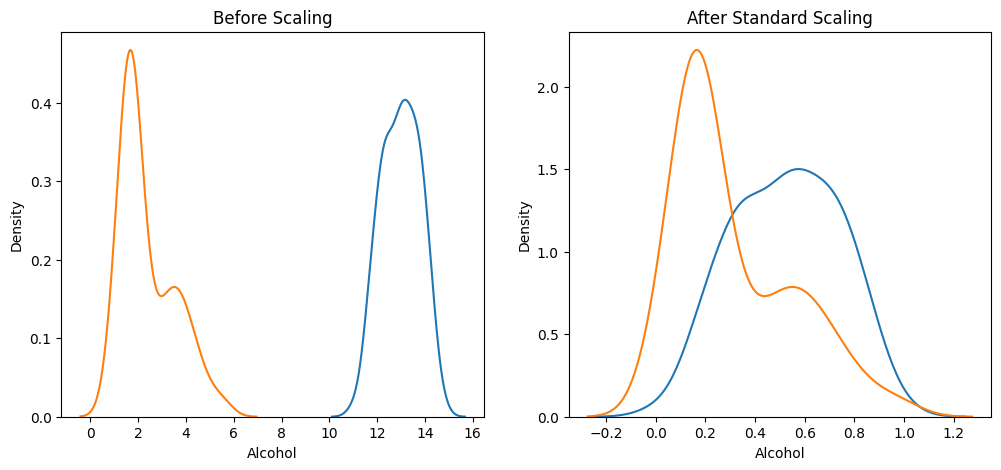

In [60]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)
plt.show()

Both comes into the same range

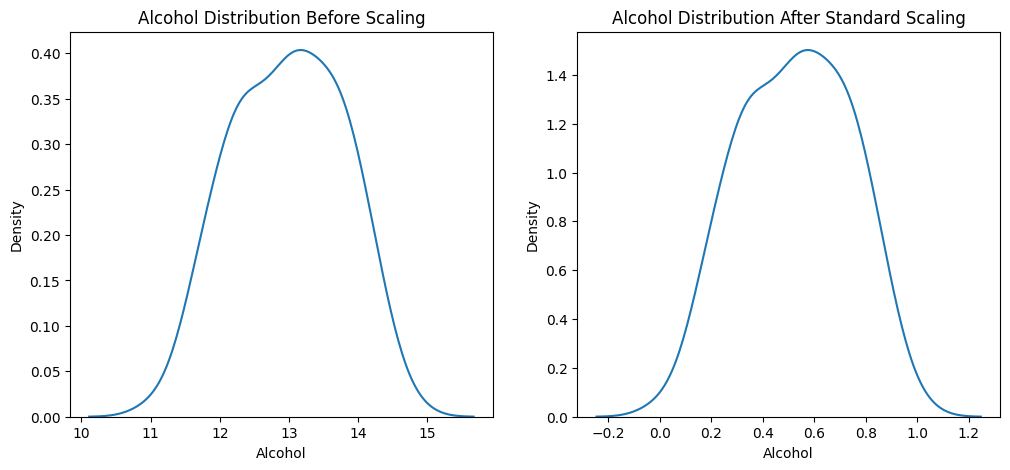

In [64]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

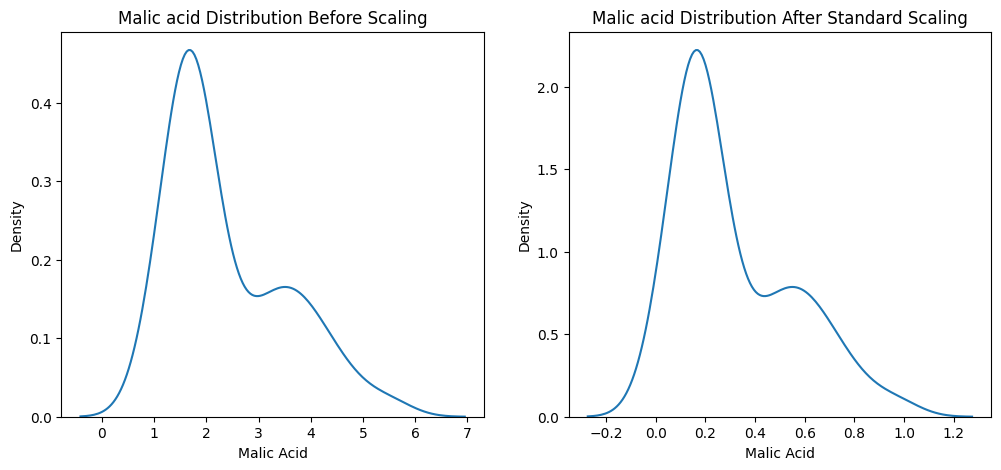

In [66]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)
plt.show()